In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
from flopy.utils import Raster
import flopy
from rasterio.features import rasterize
from scipy.spatial import cKDTree
from flopy.discretization import StructuredGrid
from shapely.geometry import LineString, MultiLineString, MultiPoint, Point, Polygon
from pathlib import Path

In [2]:

coastline = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\coastline_yucatan.shp')
yucatan_raster = Raster.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\dem_yucatan2.tif") 
cenotesRing = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\cenotesRing.shp')
df = pd.read_csv("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\piezometric_median_1996_2025_with_Weights.csv") # piezometric heads values
well_data = gpd.read_file("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\wells_yucatan.shp") ## water extraction data by municipality
south_boundary = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\south_boundary.shp')
population_raster = Raster.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\population.tif") # population density raster
data= xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\netCDF\\data_stream-moda.nc", chunks={"time":24, "latitude":400, "longitude":400}) ## Climate data for evaporation package, NetCDF4 data file format
pressure_data = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\pressure_data\\data_stream-moda_stepType-avgua.nc")
## load Yucatan polygon in geographic CRS (EPSG:4326)
yucatan = gpd.read_file("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\yucatan_state.shp") ## yucatan state polygon in CRS>4326
yucatanRaster_remuestreado = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatanRaster_remuestreado.npy")

C:\Users\sebas\AppData\Local\Temp\ipykernel_13956\3514841336.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  data= xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\netCDF\\data_stream-moda.nc", chunks={"time":24, "latitude":400, "longitude":400}) ## Climate data for evaporation package, NetCDF4 data file format


In [3]:
# Create the flopy simulation object
modelname='struc_caseC'
sim = flopy.mf6.MFSimulation(sim_name=modelname, exe_name='mf6', version='mf6', sim_ws='.')

In [4]:
with rasterio.open("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\dem_yucatan2.tif") as src:
    print("CRS:", src.crs)
    print("Resolution:",src.res)
    print("Bounds: ", src.bounds)
    bounds = [src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top]

CRS: PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolution: (14.811454703952203, 14.811454696729117)
Bounds:  BoundingBox(left=142384.3855, bottom=2161902.4815, right=444819.4791, top=2395108.8357)


In [5]:
## Creation of the modelgrid
rot = 0
nrow = 400
ncol = 400
nlay = 2
lx = int(bounds[2] - bounds[0])
ly = int(bounds[3] - bounds[1])
delr = np.ones((ncol,)) * (lx/ncol)
delc = np.ones((nrow,)) * (ly/nrow)

top = np.ones((nrow, ncol)) 
botm = np.ones((nlay, nrow, ncol))

### THIS MODELGRID IS FOR CREATE THE NEXT USEFUL MODELGRID OF THE SIMULATION CASE A 
modelgrid = StructuredGrid(
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    botm=botm,
    angrot=0.0,
    top=top,
    delc=delc,
    nlay=nlay,
    xoff=bounds[0],
    yoff=bounds[1],
    #idomain=idomain,
    lenuni=2,
    crs=32616
)

In [6]:
### CREATE THE FLOPY TEMPORAL DISCRETIZATION OBJECT
tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
    sim, pname='tdis', time_units='SECONDS', nper=1, perioddata=[(1.0,1,1.0)]
)

In [7]:
## create the new modelgrid with the data of the yucatan's raster file
## we set the bottom layers using a two-layers model with 50 and 150 depth, respectively.
NODATA = 32767.0

idomain = np.where(yucatanRaster_remuestreado == NODATA,0,1)
idomain = np.stack([idomain, idomain], axis=0)
##
top = yucatanRaster_remuestreado.astype(float)
top[idomain[0] == 0] = np.nan ## for plottings and statistics
top_filled = np.where(np.isnan(top),0.0,top)

#raw mask of upland
upland_mask = (idomain[0]==1) & (top_filled >= 50.0)

botm1_thickness = 50.0
botm2_thickness = 200.0
botm_layer1 = top_filled - botm1_thickness
botm_layer1[upland_mask] = top[upland_mask] - 300.0 #making the upland zone with more thickness (300 m of thickness in this region)
#
botm_layer2 = botm_layer1 - botm2_thickness


btm = np.stack([botm_layer1, botm_layer2],axis=0)
# ##
btm[0] = np.where(idomain[0] == 1, btm[0],0.0)
btm[1] = np.where(idomain[1] == 1, btm[1],0.0)


modelgrid._top = top_filled
modelgrid._botm = btm
modelgrid.idomain = idomain

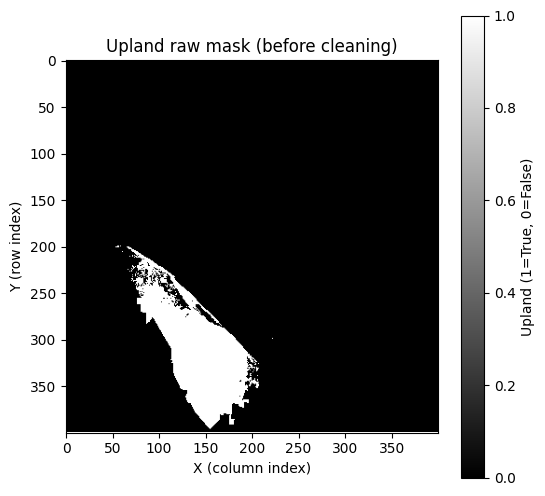

In [8]:
# z = top_filled.astype(float)
# idom1 = (idomain[0] == 1)
# z_threshold = 50.0
# #raw mask of upland
# upland_raw = (idom1) & (z >= z_threshold)

# upland_clean = binary_dilation(upland_raw, np.ones((3,3)))
# upland_clean = binary_erosion(upland_clean, np.ones((3,3)))

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(upland_mask, cmap='gray', origin='upper')
ax.set_title("Upland raw mask (before cleaning)")
ax.set_xlabel("X (column index)")
ax.set_ylabel("Y (row index)")

plt.colorbar(im, ax=ax, label="Upland (1=True, 0=False)")
plt.show()

In [9]:
## CREATE THE FLOPY GROUNDWATER FLOW MODEL OBJECT
#gwf = flopy.mf6.ModflowGwf(sim,modelname=modelname, newtonoptions='under_relaxation')
gwf = flopy.mf6.ModflowGwf(sim,modelname=modelname)

In [10]:
### CREATE HE FLOPY INTERACTIVE MODEL SOLVER (IMS) PACKAGE OBJECT
ims = flopy.mf6.modflow.mfims.ModflowIms(sim,pname='ims',

                                         complexity='SIMPLE', # chooses a set of a reasonable defaults and lighter logging.

                                         outer_dvclose=1e-3, ## convergence criterion for the outer (non-linear) loop based on the max change in primary variables (heads). Stops outer iterations when thr max head change between consecutive outer iterations is < 1e-3 (meters)


                                         outer_maximum=300, #hard cap (limit) on the number of outer iterations per time step.... if you hit this number, the non-linear problem isn't settling (often a physics/etup issue, not just solver settings).


                                         inner_dvclose=1e-6,  ## convergence criterion for the inner (linear) solver, it stops the Krylov/CG iterations when the solution update is small enough.
                                                              ## typical range: 1e-4 to 1e-6 (dimesionless, solver-norm based), for stability with unconfined flow, 1e-5 or 1e-6 can reduce outer churn (fewer outer steps wasted on sloppy inner solves).

                                         inner_maximum=1200, # hard cap on inner iterations per outer step. If you frequently hit this cap, the matrix is hard to solve (constrant in K, dry/rewet, weird BCs)

                                         linear_acceleration="BICGSTAB", ## chooses the iterative linear solver. BICGSTAB: handles non-symmetric, ill-conditioned systems better tahn CG--good for unconfined and heterogeneus cases. CG:is fine (and often faster) for symmetric positive definite systems (e.g., confined, gentle K fileds). If CG stalls, go back to BICGSTAB

                                         relaxation_factor=0.92 ## damps updates in the outer loop (under-relaxation). 1.0 = no damping (fast but can oscillat/diverge). 0.7-0.98: is common. 0.97is a gentle brake--good for unconfined/coastal models.
                                                                 # if you see oscillation (outer iterations bouncing), drop to 0.9-0.95
                                                                 # if it's painfully slow but stable, try 0.98-0.99
                                        )

In [11]:
## CREATE THE FLOPY GROUNDWATER FLOW DISCRETIZATION OBJECT 
dis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    gwf,
    pname='dis',
    nlay=modelgrid.nlay,
    nrow=modelgrid.nrow,
    ncol=modelgrid.ncol,
    delr=modelgrid.delr,
    delc=modelgrid.delc,
    top=modelgrid.top,
    botm=modelgrid.botm,
    idomain=modelgrid._idomain,
)
gwf.modelgrid.set_coord_info(xoff=modelgrid._xoff, yoff=modelgrid._yoff, angrot=modelgrid._angrot, crs=modelgrid._crs)

[<AxesSubplot:title={'center':' top'}>,
 <AxesSubplot:title={'center':'botm layer 1'}>,
 <AxesSubplot:title={'center':'botm layer 2'}>,
 <AxesSubplot:title={'center':'idomain layer 1'}>,
 <AxesSubplot:title={'center':'idomain layer 2'}>]

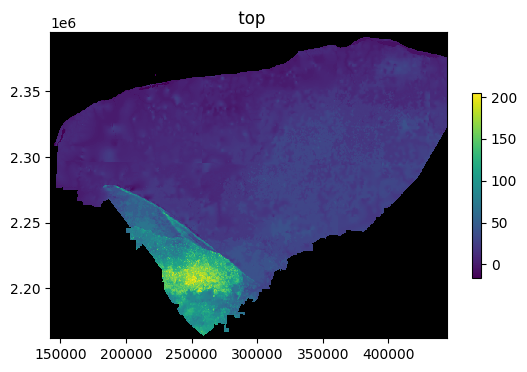

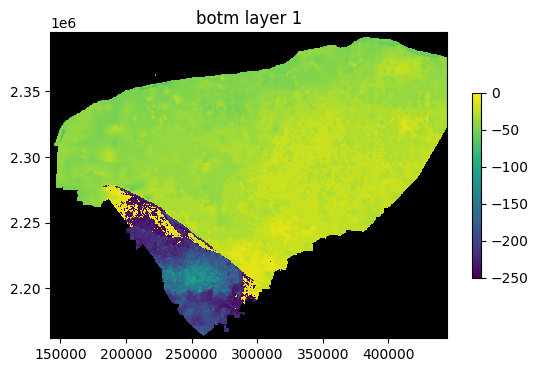

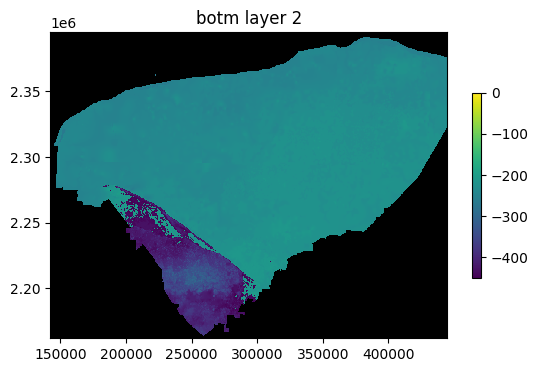

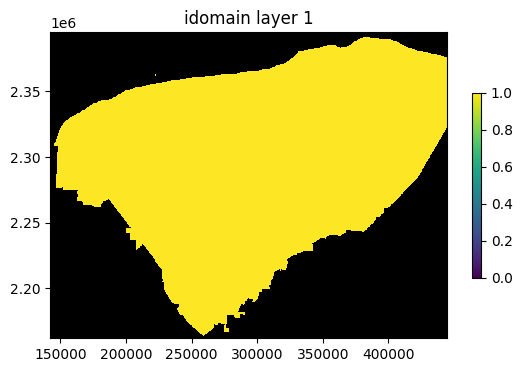

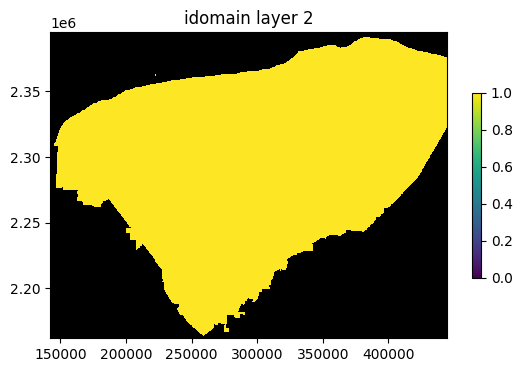

In [12]:
dis.plot()

INTERPOLATION OF PIEZOMETRIC DATA

In [13]:
## Mapping of each well to it model cell (row,col) so we can:
# (a) drop point outside the model
# (b) test plausibility against top/bottom

#ij = [modelgrid.intersect(x,y) for x,y in zip(df.x,df.y)] ## mg.intersect: returns (row,col) of the cell that contains the X,Y point
                                                          ## returns None if the points is outside the grid extent  

In [14]:
# ok = []
# idom0= gwf.dis.idomain.array[0]
# for k,rc in enumerate(ij):
#     if rc is None:
#         ok.append(False) #outside the modelgrid ----> DROP
#         continue
#     r,c = rc ## row, column
#     if idom0[r,c] != 1:
#         ok.append(False)  ## inactive cells ----> DROP
#         continue
#     h = float(df.median_head_masl.iloc[k])

#     # Plausability check: head must be above deepest bottom + small buffer,
#     # and not way above ground (top + 10 m wiggle room to tolerate outliers)
#     if np.isfinite(h) and (h>=btm[-1,r,c]+0.5) and (h<=top_filled[r,c]+10.0):
#         ok.append(True)
#     else:
#         ok.append(False)
# df = df.loc[ok].copy() ##keep only good points

In [15]:
### BUILDING OBSERVATION ARRAYS FOR INTERPOLATION

# observed wells coordinates in meters
xy_obs = np.vstack([df.x.values, df.y.values]).T #shape [n_points,2]

z_obs = df.median_head_masl.values.astype(float) #head at wells
w_obs = df.weight.values.astype(float)  #weigts 0-1 (more measurements -> higher weight)

w_obs = np.clip(w_obs,1e-6,None) #prevents divide-by-zero

In [16]:
## Building the query grid = model cell centers to interpolate onto
# modelgrid.xcellcenters, modelgrid.ycellcenters ----> 1D arrays of X and Y for each column/row

Xc, Yc = modelgrid.xcellcenters, modelgrid.ycellcenters
xy_q = np.vstack([Xc.ravel(),Yc.ravel()]).T #shape [nrow*ncol,2]

In [17]:
def idw_weighted_knn(xy_obs, z_obs, w_obs, xy_q,k, power, eps=1e-12, exact_tol=1e-9,normalize_weights=True, return_diag=False):

    # 1) filter invalid obs
    obs_ok = np.isfinite(z_obs) & np.isfinite(w_obs)
    xy_o = xy_obs[obs_ok]; z_o = z_obs[obs_ok]; w_o = w_obs[obs_ok]
    if xy_o.shape[0] == 0:
        raise ValueError("No valid observations after filtering.")

    # 2) clamp k
    k = int(min(max(1, k), xy_o.shape[0]))

    # 3) normalize obs weights (optional but helpful)
    w = np.clip(w_o, 1e-12, None)
    if normalize_weights:
        med = np.nanmedian(w)
        if np.isfinite(med) and med > 0:
            w = w / med

    # 4) KD-tree query
    tree = cKDTree(xy_o)
    dist, idx = tree.query(xy_q, k=k, p=2, workers=-1)
    if k == 1:
        dist = dist[:, None]
        idx  = idx[:,  None]

    # 5) exact matches
    exact = dist[:, 0] <= exact_tol

    # 6) weights (avoid inf, 0)
    d = np.maximum(dist, eps)
    wd = (w[idx] / d**power)
    wd_sum = wd.sum(axis=1)

    # 7) interpolate
    zi = np.full(xy_q.shape[0], np.nan, dtype=float)
    not_exact = ~exact
    if np.any(not_exact):
        num = np.sum(wd[not_exact] * z_o[idx[not_exact]], axis=1)
        den = np.maximum(wd_sum[not_exact], eps)
        zi[not_exact] = num / den

    # 8) copy exact obs values directly
    if np.any(exact):
        zi[exact] = z_o[idx[exact, 0]]

    if return_diag:
        return zi, {"exact": exact, "wd_sum": wd_sum, "dist_min": dist[:,0]}
    return zi

In [18]:
head_idw = idw_weighted_knn(xy_obs,z_obs,w_obs,xy_q,12,2.0).reshape(Xc.shape)

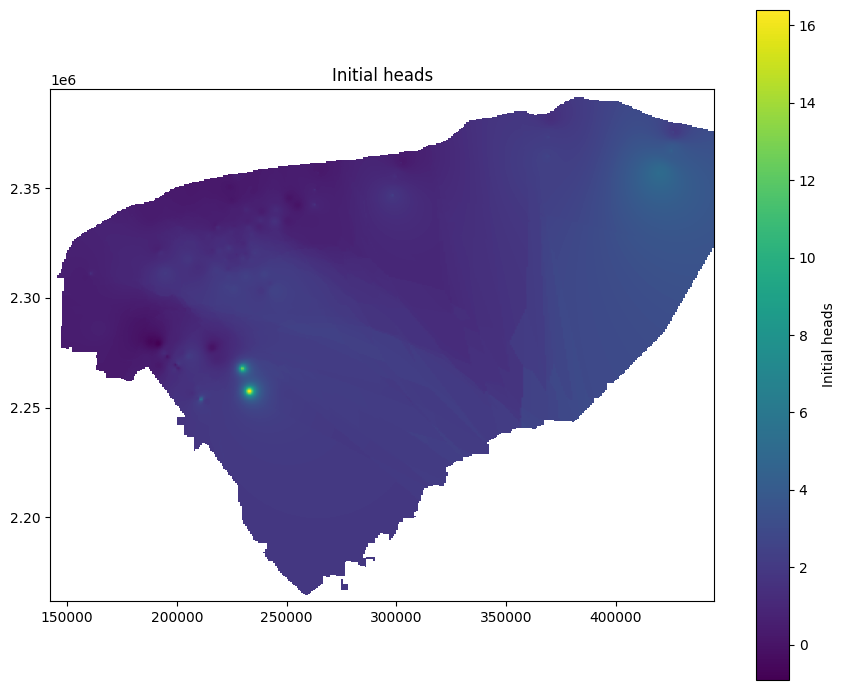

In [19]:
mask_L1 = (gwf.dis.idomain.array[0]==1)
R_plot = np.ma.masked_where(~mask_L1, head_idw)
plt.figure(figsize=(9,7))
im = plt.imshow(R_plot, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Initial heads")
plt.title("Initial heads")
plt.tight_layout(); plt.show()

[<AxesSubplot:title={'center':'strt layer 1'}>,
 <AxesSubplot:title={'center':'strt layer 2'}>]

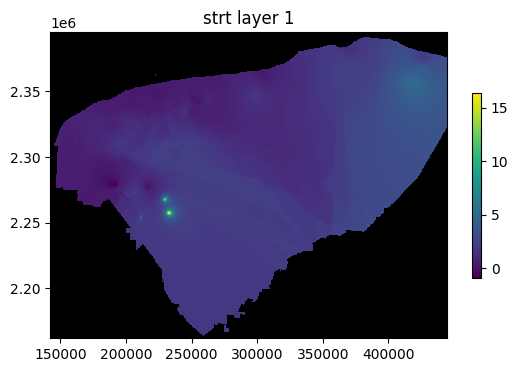

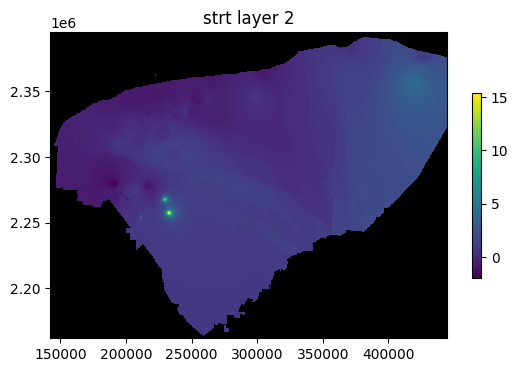

In [20]:
### CLIP TO HYDROGEOLOGY AND BUILD LAYERED INITIAL CONDITIONS (strt)
    # Layer 1: head must be within [bottom_L1 + e, top - e]
    # Layer 2: head must be <= Layer 1 >= bottom_layer2+e
    # This prevents illegal starting head and helps convergence.

idom0= gwf.dis.idomain.array[0]

#Layer 1 (upper): clip between its bottom+0.5 and top-0.5 m
strt_l1 = np.clip(head_idw,np.min(btm[0]+0.5),np.max(top_filled.max()-0.5))
#strt_l1 = np.clip(head_idw,btm[0]+0.5,top_filled-0.5)

#layer 2 (lower): not above Layer 1, not below its own bottom
strt_l2 = np.clip(np.minimum(strt_l1,head_idw-1.0), btm[1]+0.5, strt_l1)
#strt_l2 = np.clip(head_idw, btm[1]+0.5, strt_l1)

## Outside idomain, put harmless values (they are ignored by solver)
strt_l1[idom0==0] = 0.0
strt_l2[idom0==0] = 0.0 

#stacking into a 3D array [nlay,nrow,ncol]
start = np.stack((strt_l1,strt_l2), axis=0)

## Create the initial conditions package
ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname='ic', strt=start)
ic.plot()

In [21]:
from rasterio.transform import from_origin
from scipy.ndimage import binary_erosion, binary_dilation


xmin, xmax, ymin, ymax = modelgrid.extent
buf_dist = max(gwf.modelgrid.delr[0], gwf.modelgrid.delc[0])
transform = from_origin(xmin,ymax,modelgrid.delr[0],modelgrid.delc[0]) #transform from gridcells to real-world coordinates


coast_mask = rasterize(
    [(geom.buffer(1500.0),1) for geom in coastline.geometry],
    out_shape=(modelgrid.nrow,modelgrid.ncol),
    transform = transform,
    fill=0
).astype(bool)

##
coastal_cells = np.where(coast_mask & (idom0==1))
r_inds, c_inds = coastal_cells

## Build CHD entries for Layer 1 at 0.0 m.a.s.l.
chd_coast_l1 = [((0,r,c),0.0) for r,c in zip(r_inds,c_inds)]
chd_coast_l2 = [((1,r,c),0.0) for r,c in zip(r_inds,c_inds)]
chd_coast = chd_coast_l1 + chd_coast_l2

[<AxesSubplot:title={'center':' chd location stress period 1 layer 1'}>,
 <AxesSubplot:title={'center':' chd location stress period 1 layer 2'}>]

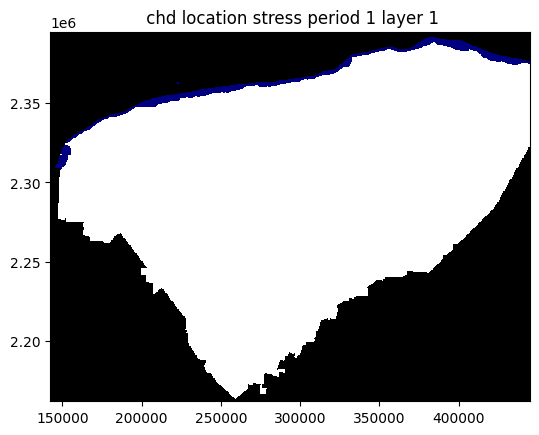

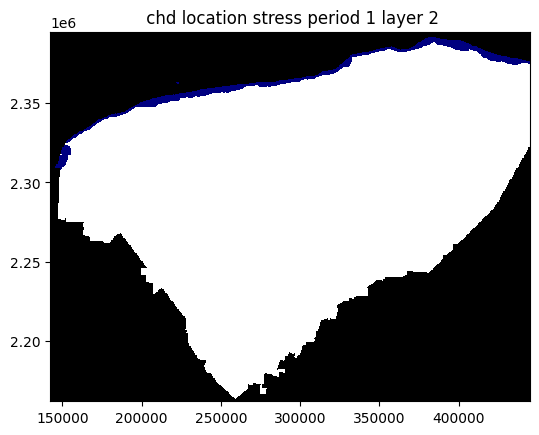

In [22]:
chd_coast = flopy.mf6.modflow.mfgwfchd.ModflowGwfchd(
    gwf,
    pname ='chd',
    stress_period_data = {0:chd_coast},
    save_flows=True,
)

# chd_upland = flopy.mf6.modflow.mfgwfchd.ModflowGwfchd(
#     gwf, pname="chd_upland",
#     filename = 'chd_upland.chd',
#     stress_period_data={0:chd_upland_data},
#     save_flows=True
# )
chd_coast.plot()

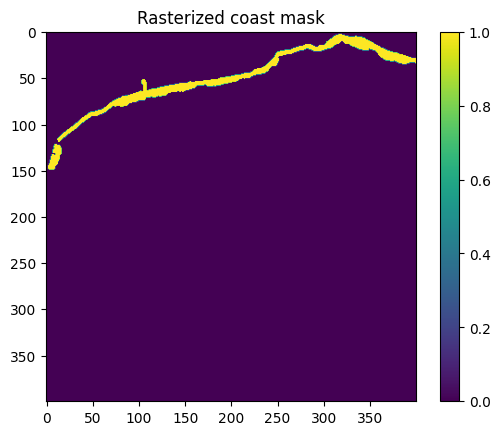

In [23]:
plt.imshow(coast_mask, origin="upper")
plt.title("Rasterized coast mask")
plt.colorbar()
plt.show()

In [24]:
# plt.imshow(upland_mask, origin="upper")
# plt.title("Rasterized upland mask")
# plt.colorbar()
# plt.show()

In [25]:
## function to create K per layer as 2D array

def as_layer_array(val):
    if np.isscalar(val):
        return np.full((modelgrid.nrow,modelgrid.ncol), float(val))
    return np.asarray(val, float)

[<AxesSubplot:title={'center':'icelltype layer 1'}>,
 <AxesSubplot:title={'center':'icelltype layer 2'}>,
 <AxesSubplot:title={'center':'k layer 1'}>,
 <AxesSubplot:title={'center':'k layer 2'}>]

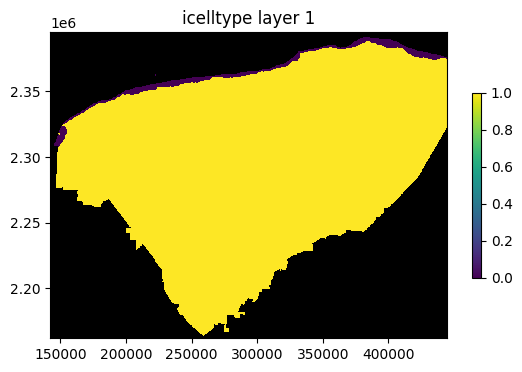

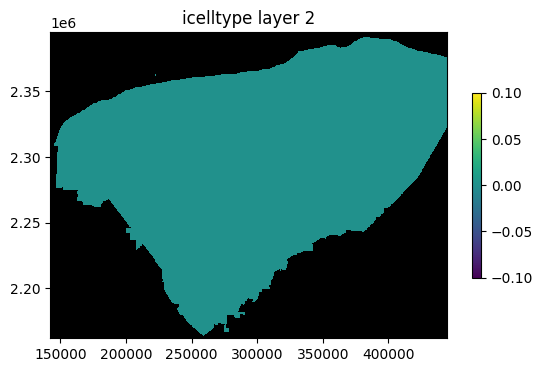

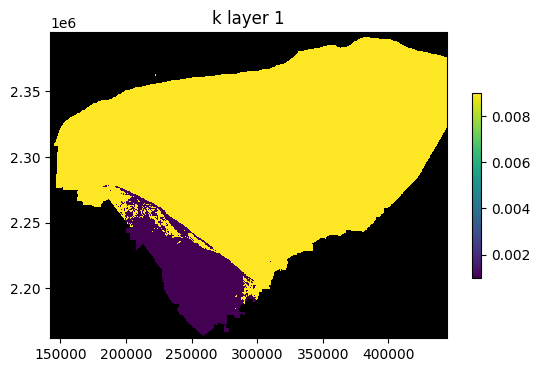

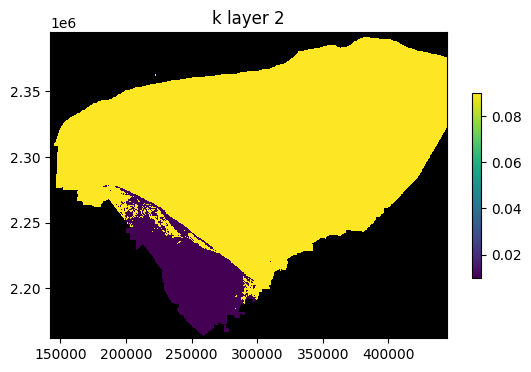

In [26]:
# Create the node property flow package
## icelltype = 1 for Layer 1 (unconfined: saturated thickness varies with computed head when head is below the cell top)
## icelltype = 0 for layer 2 (confined: means that saturated thickness is held constant)

layer1 = np.ones((modelgrid.nrow,modelgrid.ncol),dtype=int)
mask_confined = coast_mask & ((idom0==1).astype(bool))
layer1[mask_confined] = 0

icelltype = [layer1, np.zeros((modelgrid.nrow,modelgrid.ncol),dtype=int)]
#icelltype = [layer1, layer1]

k1 = as_layer_array(9e-3)
k2 = as_layer_array(9e-2)

k1 = np.where(upland_mask,1e-3,k1)
k2 = np.where(upland_mask,1e-2,k2)
k = np.stack((k1,k2), axis=0)

# k33_1 = np.where(upland_raw,1e-20,1e-2)
# k33_2 = np.where(upland_raw,1e-9, 1e-1)

# k33 = np.stack((k33_1,k33_2), axis=0)

# ## COMPUTE THE TRANSMISSIVIT FRACTIONS f1 AND f2 
# b1 = np.maximum(top-botm[0], 0.1)
# b2 = np.maximum(botm[0] - botm[1], 0.1)

### NODE PROPERTY FLOW PACKAGE CREATION 
npf = flopy.mf6.modflow.mfgwfnpf.ModflowGwfnpf(
    gwf, pname='npf', icelltype=icelltype, k=k,save_flows=True, save_specific_discharge=True,
)

npf.plot()

In [27]:
np.save("upland_cellids.npy", upland_mask)

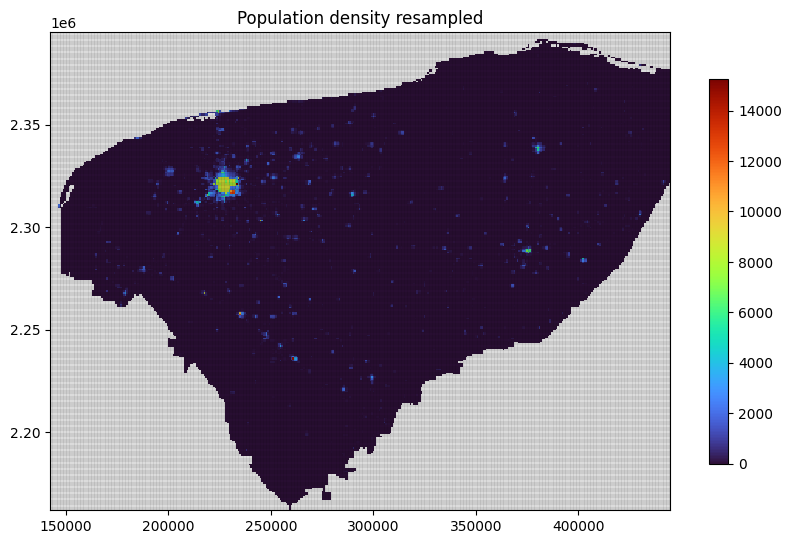

In [28]:
populationRaster_remuestreado = population_raster.resample_to_grid(modelgrid, band=population_raster.bands[0], method='nearest')
############
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid,ax=ax)
pmv.plot_grid(ax=ax, lw=0.1, color='black')
ax = pmv.plot_array(populationRaster_remuestreado, masked_values=population_raster.nodatavals, cmap="turbo")
plt.title("Population density resampled")
plt.colorbar(ax, shrink=0.5)

In [29]:
wel_list = []
idom = gwf.modelgrid.idomain
Hm3yr_to_m3s = 1e6 / (365.25*86400.0)

for idx, row in well_data.iterrows():
    Q_m3s = float(row["total"]) * Hm3yr_to_m3s
    if Q_m3s <= 0 or row.geometry is None or row.geometry.is_empty:
        continue

    muni_mask = rasterize(
        [(row.geometry, 1)],
        out_shape=(gwf.modelgrid.nrow, gwf.modelgrid.ncol),
        transform=transform,
        fill=0
    ).astype(bool)

    # Layer 2 footprint (active only) and avoid CHD if provided
    footprint = muni_mask & (idom[0].astype(bool) | idom[1].astype(bool))
    if coast_mask is not None:
        footprint &= ~coast_mask  # avoid shoreline CHD cells with the 2D coast mask

    r, c = np.where(footprint)
    if r.size == 0:
        continue

    # Population weights on footprint (spatial weights)
    w = populationRaster_remuestreado[r, c].astype(float)
    # Fallback to equal weights if population is 0/NaN
    if not np.isfinite(w).any() or np.all(w <= 0):
        w = np.ones_like(r, dtype=float)
    wsum = float(w.sum())
    if wsum <= 0:
        # extra guard
        w = np.ones_like(r, dtype=float)
        wsum = float(w.sum())

    rates = -Q_m3s * (w / wsum)

    # for rr,cc,q in zip(r,c,rates):
    #     f1_ = float(f1[rr,cc]) if idom[0,rr,cc] else 0.0
    #     f2_ = float(f2[rr,cc]) if idom[1,rr,cc] else 0.0
    #     denom = f1_ + f2_

    #     if denom <=  0.0: ## if both layers are inactive or zero T -- just skip
    #         continue
    #     if f1_ > 0:
    #         q1 = q * (f1_ / denom)
    #         wel_list.append(((0,int(rr),int(cc)), float(q1)))
    #     if f2_ > 0:
    #         q2 = q * (f2_ / denom)
    #         wel_list.append(((1,int(rr),int(cc)), float(q2)))

    for rr,cc, q in zip(r,c,rates):
        wel_list.append(((1,int(rr),int(cc)), float(q)))

##### CREATE OF THE WELL PACKAGE 
wel = flopy.mf6.modflow.mfgwfwel.ModflowGwfwel(
    gwf, pname="well_caseC", save_flows=True,
    stress_period_data={0: wel_list}   # <= dict, not bare list
)
print(f"WEL cells: {len(wel_list)} | total pumping m3/s = {sum(q for _, q in wel_list):.6f}")

WEL cells: 87488 | total pumping m3/s = -76.709481


[<AxesSubplot:title={'center':' well_casec location stress period 1 layer 1'}>,
 <AxesSubplot:title={'center':' well_casec location stress period 1 layer 2'}>]

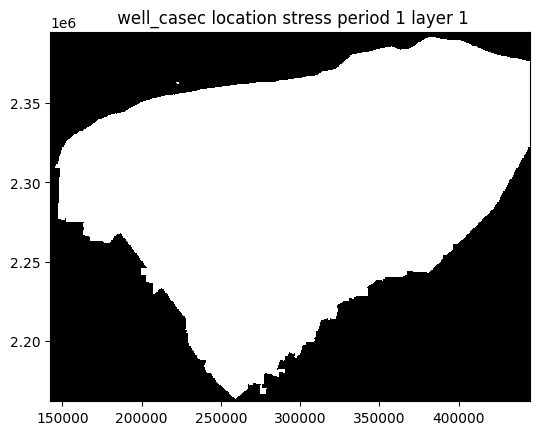

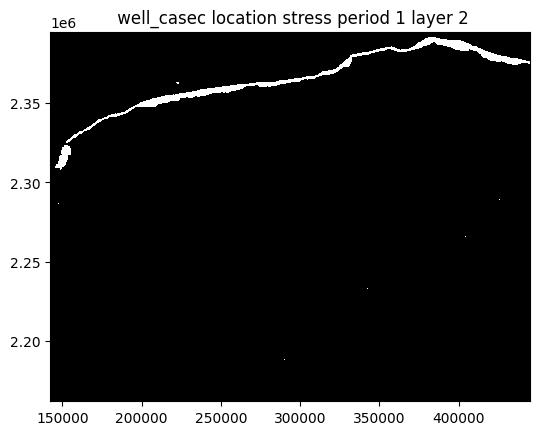

In [30]:
wel.plot()

Text(0.5, 1.0, 'WEL cells – Layer 2')

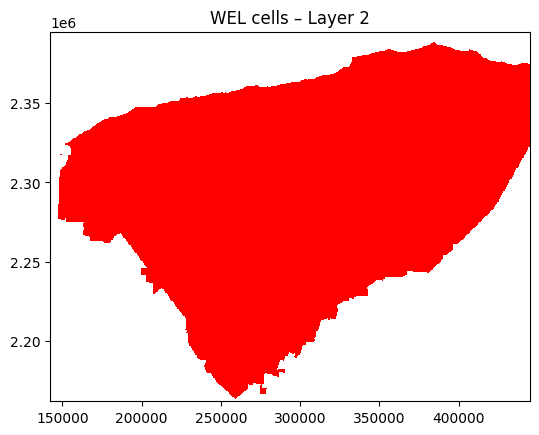

In [31]:
# Layer 0 (should be empty)
# pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
# pmv.plot_bc("WEL", kper=0)
# pmv.ax.set_title("WEL cells – Layer 1 (should be none)")

# Layer 1 (your wells)
pmv = flopy.plot.PlotMapView(model=gwf, layer=1)
pmv.plot_bc("WEL", kper=0)
pmv.ax.set_title("WEL cells – Layer 2")

In [32]:
### loading the evaporation and precipitation data 
x = []
y = []
prec_values = []
prec_weight_values = []

folder = Path("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\precipitation_data")
for fp in folder.glob("*.csv"):
    #read the file
    df = pd.read_csv(fp)
    # ## extract coordinates values
    x_val = df["x"].dropna().values
    y_val = df["y"].dropna().values
    x.extend(x_val)
    y.extend(y_val)
    # extract precipitation data value
    prec_data = (df["mean_of_acum"].dropna().values) 
    prec_values.extend(prec_data) 
    # extract the weight data
        #For the case A use 25% of mean annual precipitation
    #weight_data = (df["weight"].dropna().values) * 0.25
    weight_data = (df["weight"].dropna().values) 
    prec_weight_values.extend(weight_data)
    
x_coords = np.array(x)
y_coords = np.array(y)
clima_coords = np.column_stack((x_coords, y_coords))
prec_values = np.array(prec_values)
prec_weight_values = np.array(prec_weight_values)

In [33]:
### interpolation of the precipitation data
prec_idw = idw_weighted_knn(clima_coords,prec_values,prec_weight_values,xy_q,12,2.0).reshape(Xc.shape)

[<AxesSubplot:title={'center':' rch location stress period 1 layer 1'}>,
 <AxesSubplot:title={'center':' rch location stress period 1 layer 2'}>]

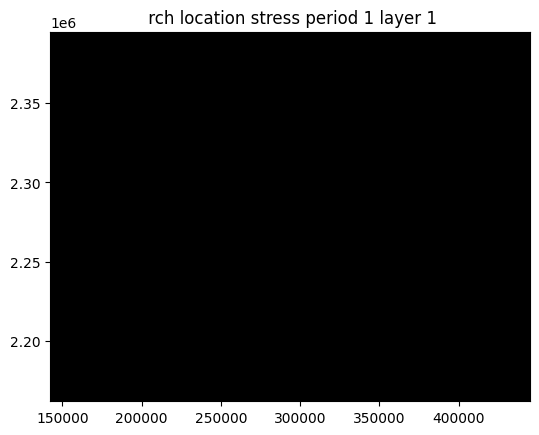

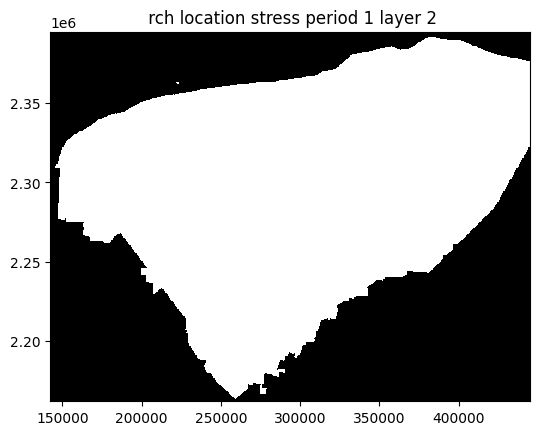

In [34]:
## creating the recharge package
sec_per_year = 365*86400 #seconds in a year
c_inf = 0.25 #infiltration coefficient
## mask to active cells
idom = gwf.dis.idomain.array
idom0 = (idom[0]==1)
recharge = (prec_idw*1e-3*c_inf) / sec_per_year #recharge in meters per seconds
mR_upland = 1.0
mR_rest = 1.0

recharge[idom0 & upland_mask] *= mR_upland
recharge[idom0 & (~upland_mask)] *= mR_rest


records = [((0, r, c), float(recharge[r, c]))
           for r in range(recharge.shape[0])
           for c in range(recharge.shape[1])
           if idom0[r, c]]


if "rch" in gwf.get_package_list():
    gwf.remove_package("rch")
    
# CREATE THE RECHARGE (PRECIPITATION DATA) PACKAGE
rch = flopy.mf6.ModflowGwfrch(
    gwf,
    stress_period_data = {0:records}, #steady state; 1 period
    pname="rch",
    fixed_cell=True,
    print_flows=True,
    filename = "struc_caseC.rch",
    save_flows=True,
)

rch.plot()

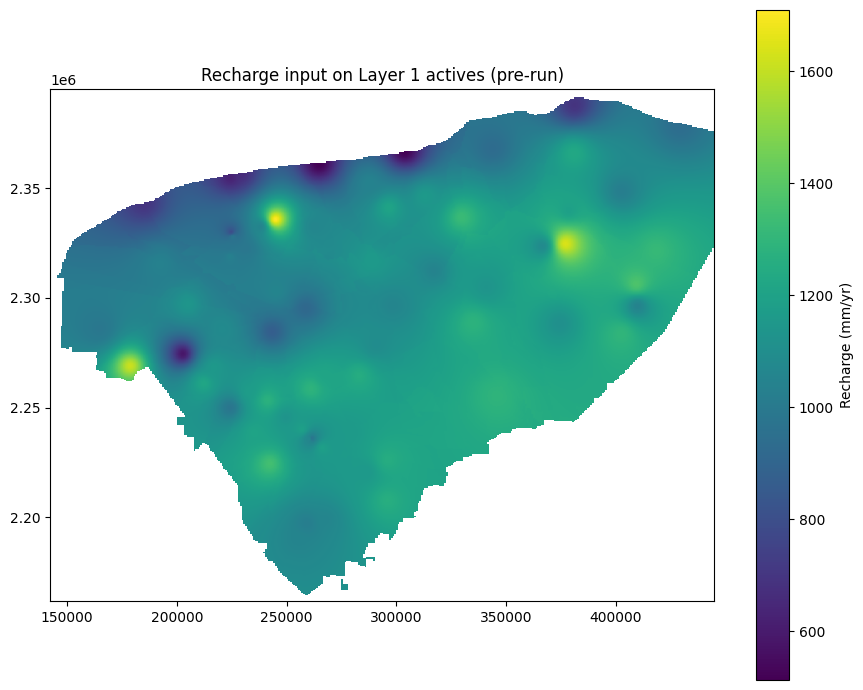

In [35]:
mask = (gwf.dis.idomain.array[0]==1)
data_prec = np.ma.masked_where(~mask, prec_idw)
plt.figure(figsize=(9,7))
im = plt.imshow(data_prec, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Recharge (mm/yr)")
plt.title("Recharge input on Layer 1 actives (pre-run)")
plt.tight_layout(); plt.show()

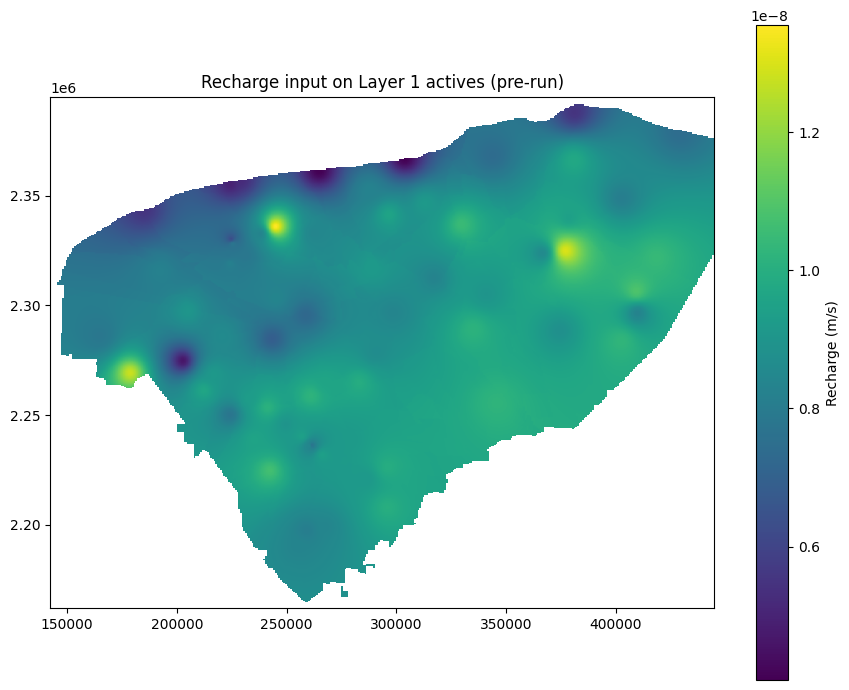

In [36]:
mask_L1 = (gwf.dis.idomain.array[0]==1)
R_plot = np.ma.masked_where(~mask_L1, recharge)
plt.figure(figsize=(9,7))
im = plt.imshow(R_plot, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Recharge (m/s)")
plt.title("Recharge input on Layer 1 actives (pre-run)")
plt.tight_layout(); plt.show()

In [37]:
## LOADING OF THE NETCDF DATA (CLIMATOLOGY DATA)

d2m_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\d2m_m.nc")
t2m_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\t2m_m.nc")
ssr_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\ssr_m.nc")
str_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\str_m.nc")
u10_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\u10_m.nc")
v10_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\v10_m.nc")

In [38]:
# CONVERT UNITS AND COMPUTE ET0 (MONTHLY)
# radiation [J/m2] per month ----> MJ/m2/day; temps K---->°C; wind to 2 m, etc..

time = ssr_m['valid_time'].to_index() #taks the "time" coordinate of my NetCDF variable and converts it into Pandas index (likely DatetimeIndex) so i can use pandas functionality on it.

days_in_month = xr.DataArray(
    time.to_series().dt.days_in_month.values,
    coords={'valid_time' : ssr_m['valid_time']}
)  # ----> This code builds an xarray DataArray where each time step stores the number of days in its month. It lines up perfectly with my NetCDF time dimension, so i can use it later for calculations 

# Convert units of solar and thermal radiation to MJ/m2/day(MJ/m2 per day),  (before J/m2 per month)
Rns = (ssr_m['ssr']/ days_in_month) / 1e6 #now daily average shortwave radiation 
Rnl = (str_m['str'] / days_in_month) / 1e6 #now daily average longwave radiation
Rn = Rns + Rnl

## Convertion from K grades to °C for 2m temperature and dewpoint temperature
Tmean_C = t2m_m['t2m'] - 273.15 
Tdew_C = d2m_m['d2m'] - 273.15

# Wind: 10 m ----> 2 m 
u10 = np.hypot(u10_m['u10'], v10_m['v10'])  # -----> here im computing the magitude of the wind vector (speed in m/s) at 10 meters above the ground
u2 = u10 * (4.87 / np.log(67.8*10.0 - 5.42)) # This uses the FAO-56 ogarithmic wind profile adjusment, # ≈ 0.748*u10

## Saturation and actual vapour pressure (kPa)
def esat_kpa(Tc): return 0.6108*np.exp((17.27*Tc)/(Tc+237.3)) ## -----> This function is a saturation vapor pressure equation (the maximum water vapor pressure that air can hold at a given temperature), straight out of the FAO-56 evapotranspiration method. 
                                                                #       Saturtion vapor pressure is a key ingredient for calculating actual vapor pressure, vapor pressure deficit (VPD), and a reference evapotranspiration (ET0). Represents the water demand of the air at a given temperature.
                                                              ##        Output: Units = kilopascals (kPa)


## The difference between (es-ea) is the vapor pressure deficit (VPD), i.e., how "dry" the air is
#  Units : kPa
es = esat_kpa(Tmean_C) ## ---> saturation vapor pressure at mean air temperature
ea = esat_kpa(Tdew_C) ## ---> actual vapor pressure at dew-point temperature -- dew point is when air is saturated, so it´s actual vapor pressure 

#Slope of vapour pressure curve (kPa/°C): formula from FA0-56: slope of saturation vapor pressure curve at kPa/°C (it measures how sensitive vapor pressure is to temperature)
delta = (4098.0 * es) / ((Tmean_C + 237.3)**2)   

# Convert Pa to kPa
#P_kPa = pressure_m / 1000.0
P_kPa = xr.zeros_like(Tmean_C) + 101.3
gamma = 0.000665 * P_kPa # psychrometric constant gamma (kPa/°C)

## FAO-56 PM (mm/day); soil heat flux G ~ 0 monthly
T_k = Tmean_C + 273.0 # converts air temperature in °C to Kelvin; needed because the ET0 formula has a term 900/T where T must be in Kelvin.
ET0 = (0.408*delta*Rn + gamma*(900.0/T_k)*u2*(es-ea)) / (delta + gamma*(1.0 + 0.34*u2)) # this is the FAO-56 Penman-Monteith reference evapotranspiration equation (mm/day)
ET0 = ET0.clip(min=0.0) ## no negative values 

In [39]:
fgw = 0.3 #groundwater fraction
exdp_val = 2.0

idom2d = (gwf.modelgrid.idomain[0] == 1)
rate_mps = (fgw*ET0*1e-3) / 86400.0 ##mm/d ---> m/s
rate_mps_mm_yr = fgw*ET0
##map to active cells
surf = top_filled.astype(float)
exdp = np.full_like(surf, exdp_val, dtype=float)

rate_ss = rate_mps.mean(dim='valid_time').values ## rate of maximum EVT flux rate 
rate_ss_mmYr = rate_mps_mm_yr.mean(dim='valid_time').values
# build records only where active and ET>0
spd0 = []
maskk = idom2d & (rate_ss > 0)
evt_mask = maskk & ~coast_mask
r_idx, c_idx = np.where(evt_mask)
for r,c in zip(r_idx, c_idx):
    spd0.append([(0, int(r), int(c)), float(surf[r,c]), float(rate_ss[r,c]), float(exdp[r,c])])

evt = flopy.mf6.modflow.mfgwfevt.ModflowGwfevt(
    gwf, pname='evt',
    maxbound = len(spd0), #integer values specifying the maximum number of evapotranspiration cells that will be specified for use during any stress period
    stress_period_data = {0: spd0}, #dictionary keyed by stress period
    save_flows=True,
    nseg=1 # single linear segment
)

print(f"EVT cells (SS): {len(spd0)}")

# FOR TRANSIENT MONTHLY MODE

# # Build TDIS first with one period per month (SECONDS)
# months = rate_mps['time'].to_index()
# perlens = (months.to_series().dt.days_in_month.values * 86400.0).astype(float)
# perioddata = [(float(p), 1, 1.0) for p in perlens]
# tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
#     sim, pname='tdis', time_units='SECONDS',
#     nper=len(perioddata), perioddata=perioddata
# )

# # Build EVT SPD per month
# evt_spd = {}
# for sp, _ in enumerate(months):
#     rate2d = rate_mps.isel(time=sp).values  # m/s
#     spd = []
#     r_idx, c_idx = np.where(idom2d & (rate2d > 0))
#     for r, c in zip(r_idx, c_idx):
#         spd.append([(0, int(r), int(c)), float(surf[r, c]), float(rate2d[r, c]), float(exdp[r, c])])
#     evt_spd[sp] = spd

# evt = flopy.mf6.modflow.mfgwfevt.ModflowGwfevt(
#     gwf, pname='evt_monthly',
#     maxbound=max(len(v) for v in evt_spd.values()),
#     stress_period_data=evt_spd,
#     save_flows=True,
#     nseg=1
# )
# print("EVT monthly built. Example SP0 entries:", len(evt_spd[0]))


EVT cells (SS): 86632


In [40]:
## OUTPUT CONTROL PACKAGE
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord="struc_caseC.hds",
    budget_filerecord = "struc_caseC.cbc",
    saverecord=[("HEAD","LAST"), ("BUDGET","LAST")],
    printrecord=[("BUDGET","LAST")]

)

In [41]:
## write simulation
success = sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model struc_caseC...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 4424 based on size of stress_period_data
    writing package npf...
    writing package well_casec...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 87488 based on size of stress_period_data
    writing package rch...
INFORMATION: maxbound in ('gwf6', 'rch', 'dimensions') changed to 89705 based on size of stress_period_data
    writing package evt...
    writing package oc...


In [42]:
ok, buff = sim.run_simulation()

FloPy is using the following executable to run the model: ..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.0 12/20/2024

   MODFLOW 6 compiled Dec 31 2024 17:10:16 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS n

In [43]:
# from flopy.utils import Mf6ListBudget

# lst = Mf6ListBudget(f"{modelname}.lst")
# df, _ = lst.get_dataframes()

# print(df.columns) 
# print(df.head(10))

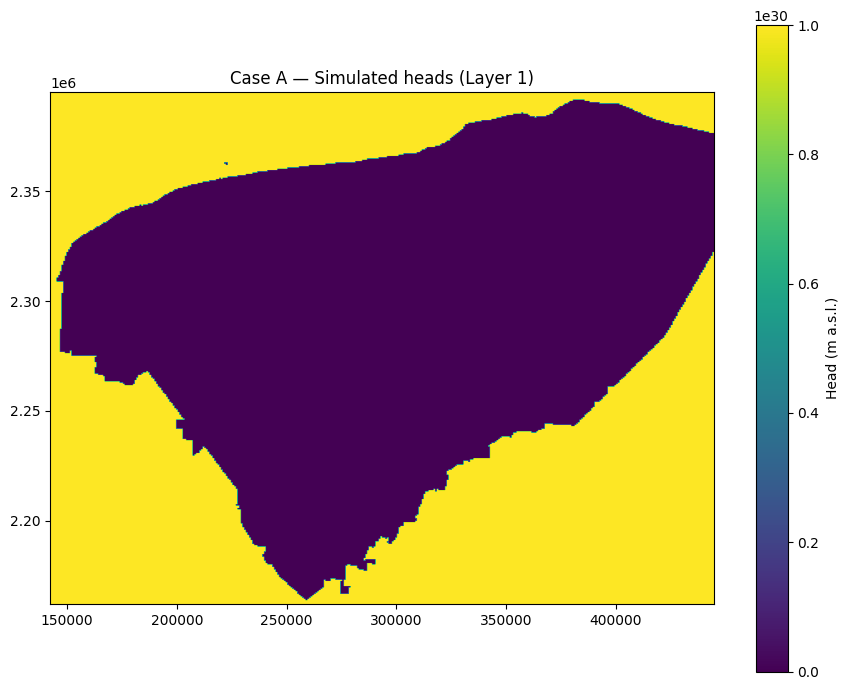

Budget record names: [b'    FLOW-JA-FACE', b'      DATA-SPDIS', b'             WEL', b'             RCH', b'             EVT', b'             CHD']


In [44]:
# Heads (steady-state → one output)
hobj = gwf.output.head()
h = hobj.get_data(kstpkper=(0,0))           # shape (nlay, nrow, ncol)
h1 = np.where(gwf.dis.idomain.array[0]==1, h[0], np.nan)

plt.figure(figsize=(9,7))
im = plt.imshow(h[0], extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im,label="Head (m a.s.l.)")
plt.title("Case A — Simulated heads (Layer 1)")
plt.tight_layout(); plt.show()

# Budget summary
bud = gwf.output.budget()
# MF6 prints a summary in console via OC; here’s a quick check of net imbalance:
from flopy.utils.utils_def import totim_to_datetime
# total IN and OUT from budget text (optional: parse bud file)
recnames = bud.get_unique_record_names()
print("Budget record names:", recnames)

In [45]:
h.shape

(2, 400, 400)

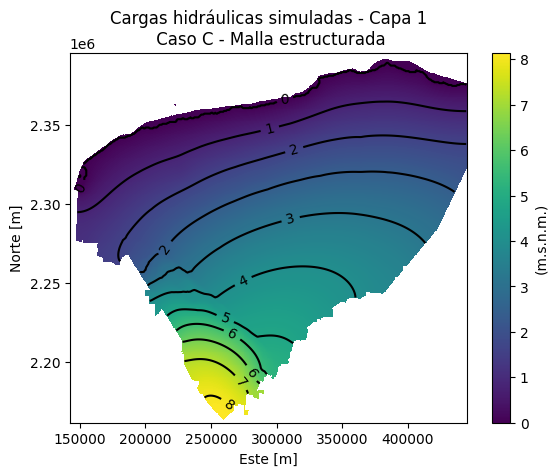

In [46]:
# vmin = int(h[0].min())
# vmax = int(h[0].max())
#levels=np.arange(vmin,vmax,10)
#levels = np.arange(vmin,vmax,100)
fig, ax = plt.subplots()
modelMap = flopy.plot.PlotMapView(model=gwf,ax=ax,layer=0)
hd = modelMap.plot_array(h[0],ax=ax,alpha=1.0,cmap='viridis')
#linecollection = modelmap.plot_grid(lw=0.4)
contour = modelMap.contour_array(h[0],ax=ax,levels=10,colors='black')
plt.colorbar(hd, label="(m.s.n.m.)")
labels = plt.clabel(contour,fmt="%1.0f")

cbc = flopy.utils.CellBudgetFile("struc_caseC.cbc", precision="double")
spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)

plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Cargas hidráulicas simuladas - Capa 1\n Caso C - Malla estructurada')
plt.show()

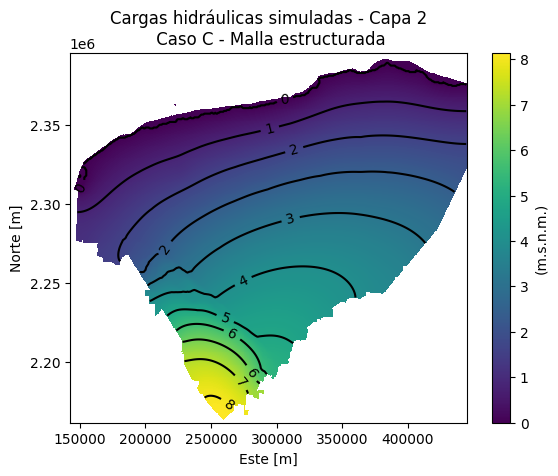

In [47]:
fig, ax = plt.subplots()
modelMap = flopy.plot.PlotMapView(model=gwf,ax=ax,layer=1)
hd = modelMap.plot_array(h[1],ax=ax,alpha=1.0, cmap='viridis')
#linecollection = modelmap.plot_grid(lw=0.4)
contour = modelMap.contour_array(h[1],ax=ax,levels=10, colors='black',
                               )
plt.colorbar(hd, label="(m.s.n.m.)")
labels = plt.clabel(contour,fmt="%1.0f")

cbc = flopy.utils.CellBudgetFile("struc_caseC.cbc", precision="double")
spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Cargas hidráulicas simuladas - Capa 2\n Caso C - Malla estructurada')
plt.show()

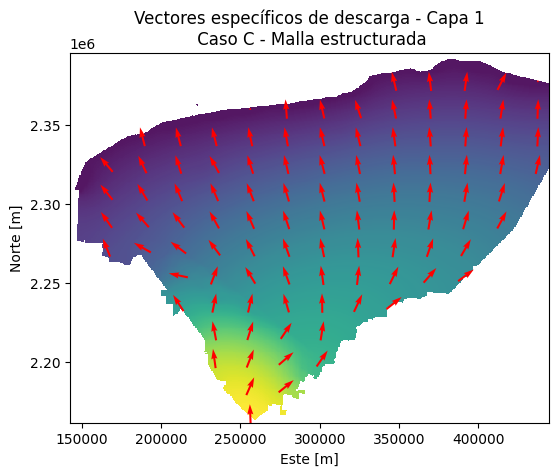

In [48]:
# Mask inactive cells in layer 1
mask0 = (idomain[0] != 1)
qx0 = qx[0].copy(); qy0 = qy[0].copy()
#qx0[mask0] = np.nan; qy0[mask0] = np.nan

# Optional: background heads for layer 1
#from flopy.utils import HeadFile
hds = flopy.utils.HeadFile("struc_caseC.hds", precision="double")
h = hds.get_data(kstpkper=(0,0))  # steady-state
h0 = h[0]; h1[mask0] = np.nan

pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
pmv.plot_array(h0, alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx0, qy0, istep=30, jstep=30,normalize=True,  color='red')
#pmv.plot_bc("CHD")  # nice sanity overlay
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Vectores específicos de descarga - Capa 1\n Caso C - Malla estructurada')
plt.show()

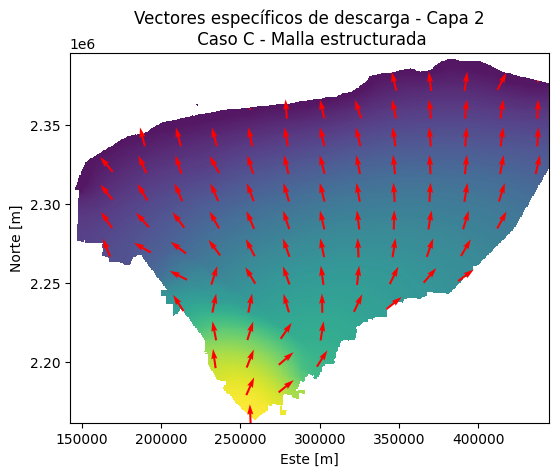

In [49]:
mask0 = (idomain[0] != 1)
qx1 = qx[1].copy(); qy1 = qy[1].copy()
qx1[mask0] = np.nan; qy1[mask0] = np.nan

# Optional: background heads for layer 1
#from flopy.utils import HeadFile
hds = flopy.utils.HeadFile("struc_caseC.hds", precision="double")
h = hds.get_data(kstpkper=(0,0))  # steady-state
h1 = h[1]; h1[mask0] = np.nan

pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
pmv.plot_array(h1, alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx1, qy1, istep=30, jstep=30,normalize=True,  color='red')
#pmv.plot_bc("CHD")  # nice sanity overlay
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Vectores específicos de descarga - Capa 2\n Caso C - Malla estructurada')
plt.show()

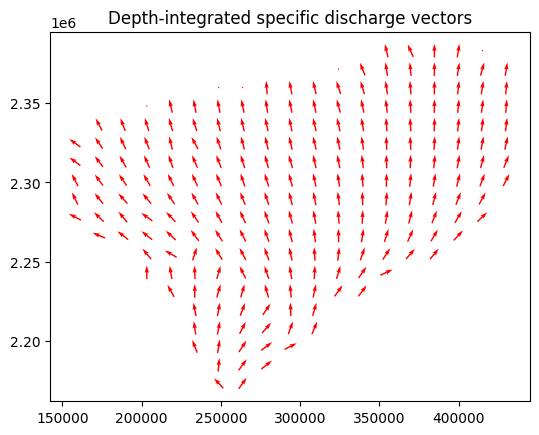

In [50]:
# Sum over layers (units remain [L/T]): this is the vertically-integrated specific discharge
qx2d = np.nansum(qx, axis=0)
qy2d = np.nansum(qy, axis=0)

# Mask with top layer idomain
qx2d[mask0] = np.nan
qy2d[mask0] = np.nan

pmv = flopy.plot.PlotMapView(model=gwf)
pmv.plot_vector(qx2d, qy2d, istep=20, jstep=20, normalize=True, color='red')  # magnitudes visible
plt.title("Depth-integrated specific discharge vectors")
plt.show()
